In [1]:
%cd ../..

/scratch/big/home/daawic/BSc-Thesis


In [2]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.models import EDMMauMau, EDMLuomen
from project.util.device import get_available_acc
from project.util.transforms import Difference
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [3]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout_test.pt")

In [4]:
device = "cuda:9"

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    Difference(),
    transforms.Normalize(0.5, 0.5),
])

In [9]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=10_000
)

In [10]:
SIGMA = 0.5

In [12]:
psnrs = []

n = 64
x = torch.zeros((n, 7, 88, 88), device=device)

for i, img in enumerate(torch.randperm(10_000)[:n]):
    x[i] = data[img].to(device)

e = SIGMA * torch.randn_like(x)
x_noisy = (x + e).clip(-1, 1)

for N in range(2, 33):

    model = EDMLuomen.from_checkpoint(PATH, device, sigma_noise=SIGMA, N=N).to(device)

    with torch.no_grad():
        x_denoised = model.denoise(x_noisy)
        psnrs.append(PSNR(x.to("cpu"), x_denoised.to("cpu"), torch.tensor(2)))
    
    print(f"Finished {N} (psnr: {psnrs[-1]})")

100%|██████████| 1/1 [00:00<00:00, 11.00it/s]


Finished 2 (psnr: 14.897109031677246)


100%|██████████| 1/1 [00:00<00:00, 10.99it/s]


Finished 3 (psnr: 14.897109031677246)


100%|██████████| 2/2 [00:00<00:00,  2.22it/s]


...

Finished 30 (psnr: 36.507415771484375)


100%|██████████| 11/11 [00:08<00:00,  1.34it/s]


Finished 31 (psnr: 35.8054084777832)


100%|██████████| 11/11 [00:08<00:00,  1.34it/s]


Finished 32 (psnr: 35.12526321411133)


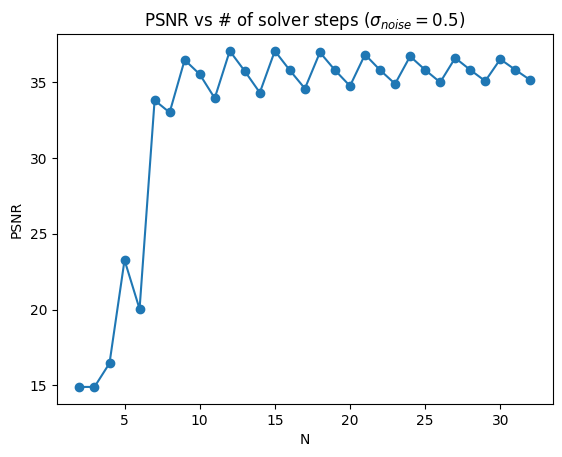

In [13]:
Ns = torch.arange(2, 33)
plt.plot(Ns, psnrs, "o-")
plt.xlabel("N")
plt.ylabel("PSNR")
plt.title("PSNR vs # of solver steps ($\\sigma_{noise} = " + str(SIGMA) + "$)")
plt.show()